# 03: Parametric curve fitting: Nelson-Siegel and Svensson

## Objective

Notebooks 01 and 02 built a curve by bootstrapping: the curve was forced through
every quote exactly, and an interpolation rule filled the gaps. That approach
treats each quote as error-free. It is the right choice when the quotes are the
instruments you are actually going to hedge with, and it is what a trading desk
marks its book against.

It is the wrong choice for several other jobs. A central bank publishing a
reference curve does not want its estimate to jump every time one bond in the
sample goes special in repo. A risk manager who wants to describe a curve move
in three numbers cannot do it with 40 bootstrapped pillars. And anyone
extrapolating past the longest traded maturity has no quotes left to interpolate
between, so something has to supply the shape.

Parametric models answer those jobs. They impose a functional form on the whole
term structure and fit its handful of parameters by least squares, accepting a
residual at every quote in exchange for smoothness, parsimony and a curve that is
defined everywhere. This notebook fits the two standard ones: Nelson-Siegel
(1987) with four parameters, and its Svensson (1994) extension with six
parameters. It applies these to the European Central Bank's published euro area
spot curve and measures what the two extra parameters buy.

A fit is only as good as its identification, so this notebook reports the fit
contract explicitly: the optimizer's own verdict, whether any parameter pressed
against its bounds, and the Jacobian rank and condition. The library's
`NelsonSiegel.fit` and `Svensson.fit` return a `ParametricFitResult` carrying
those diagnostics, and a fit that is unsuccessful, boundary-saturated or
underidentified raises `FitError` rather than silently returning a curve. Every
number quoted below is printed from such a result, not asserted.

## Data

One dataset, from the snapshot committed at `data/snapshots/2026-07-24/`:

- `ecb_spot_curve`: 14 zero rates, 1 to 30 years, from the ECB's AAA-rated euro
  area government bond yield curve. Continuously compounded, so they feed the
  models without conversion.
- `ecb_svensson_parameters`: the six Svensson parameters the ECB published for
  the same date. The ECB quotes its betas in percent; the code below divides by
  100. The taus are in years and are used directly.

The second dataset is what makes this notebook more than a curve-fitting
exercise, and it needs to be introduced honestly rather than saved for a reveal.
The ECB series key is `YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_<TENOR>`. The `SV_C_YM`
segment records the estimation method: **S**vensson model, **c**ontinuous
compounding, **y**ield error **m**inimisation. The published spot rates are not
raw market observations. They are readings taken off a Svensson curve that the
ECB had already fitted to its bond sample.

That has a consequence which is stated here at the top rather than presented
later as a result: fitting a Svensson model to these 14 points is fitting a model
to data generated by that same model — a *planted-data* exercise. The residual
should be numerically zero, and it is. What the exercise legitimately
establishes is a **verification** of this implementation: an independent
optimiser, written against its own objective function, recovers the six
parameters that generated the curve. It does not establish that Svensson fits
real bond prices well, and no claim of that kind is made below.

The genuinely independent check is the **ECB Svensson reconstruction**, named in
the repository's validation section: the ECB's *published* parameters (produced
by the ECB's own estimation from its bond sample, never seen by the fitting code
in this notebook) rebuild the published spot curve, and an independent fit lands
on the same parameters. Both directions are computed below.

The Nelson-Siegel comparison, though, becomes cleaner rather than weaker under
these conditions. Because the target is an exact Svensson curve, the
Nelson-Siegel residual is not contaminated by bid-offer noise, liquidity premia
or bonds trading special. It is a pure measurement of one thing: what is lost by
deleting the second curvature term.

## Theory

Nelson and Siegel proposed writing the *instantaneous forward* rate as a solution
to a second-order differential equation with equal roots, which produces

$$f(t) = \beta_0 + \beta_1 e^{-t/\tau} + \beta_2 \frac{t}{\tau} e^{-t/\tau}.$$

Integrating and dividing by $t$ gives the zero rate, which is the form actually
fitted:

$$z(t) = \beta_0 + \beta_1 \frac{1 - e^{-t/\tau}}{t/\tau}
         + \beta_2 \left( \frac{1 - e^{-t/\tau}}{t/\tau} - e^{-t/\tau} \right).$$

The three loadings are what give the model its interpretation. The loading on
$\beta_0$ is 1 at every maturity, so $\beta_0$ moves the whole curve: the level
factor. The loading on $\beta_1$ is 1 at $t = 0$ and decays to 0, so $\beta_1$
moves the short end relative to the long end: the slope factor. The loading on
$\beta_2$ is 0 at both ends and humped in between, so $\beta_2$ bends the middle:
the curvature factor. Consequently $\beta_0$ is the asymptotic long rate,
$\beta_0 + \beta_1$ is the instantaneous short rate, and $\tau$ sets where the
hump sits.

Those three shapes are close to what principal component analysis extracts
empirically from historical yield changes, which is why the same level-slope-
curvature vocabulary appears in both literatures. Notebook 05 runs the PCA and
the correspondence can be checked there rather than asserted here.

Svensson's extension adds a second curvature term with its own decay:

$$f(t) = \beta_0 + \beta_1 e^{-t/\tau_1} + \beta_2 \frac{t}{\tau_1} e^{-t/\tau_1}
         + \beta_3 \frac{t}{\tau_2} e^{-t/\tau_2}.$$

With $\tau_2 \neq \tau_1$ the curve can bend twice, at two separate horizons.
The practical motivation is the long end. A single hump forces the curve to
approach $\beta_0$ monotonically once past it, so a term structure that rises,
flattens and then rolls over (as when a 15 to 30 year segment rises, flattens,
and then rolls over due to duration demand from pension funds and insurers
bidding up very long bonds) cannot be reproduced by four parameters. It can by
six.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from yieldcurve.curves.parametric import FitError, NelsonSiegel, Svensson
from yieldcurve.market.snapshot import Snapshot

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

spot = snapshot.load("ecb_spot_curve").sort_values("tenor_years")
times = spot["tenor_years"].to_numpy(dtype=float)
zeros = spot["zero_rate"].to_numpy(dtype=float)

published = snapshot.load("ecb_svensson_parameters").set_index("parameter")["value"]

print(f"ECB euro area AAA spot curve, {ASOF}, {len(times)} tenors")
print(f"{'tenor (y)':>10} {'zero (%)':>10}")
for t, z in zip(times, zeros, strict=True):
    print(f"{t:>10.0f} {100 * z:>10.4f}")

print()
print("ECB published Svensson parameters (betas in percent, taus in years)")
for name, value in published.items():
    print(f"{name:>8} {value:>16.10f}")

ECB euro area AAA spot curve, 2026-07-24, 14 tenors
 tenor (y)   zero (%)
         1     2.6414
         2     2.7720
         3     2.8155
         4     2.8504
         5     2.8954
         6     2.9512
         7     3.0137
         8     3.0791
         9     3.1442
        10     3.2070
        15     3.4573
        20     3.5929
        25     3.6377
        30     3.6200

ECB published Svensson parameters (betas in percent, taus in years)
   BETA0     1.3260646820
   BETA1     0.8461755436
   BETA2     2.0922416380
   BETA3     7.3512863000
    TAU1     1.0791595160
    TAU2    15.4469075500


The curve rises from 2.64% at one year to 3.64% at 25 years and then *falls* to
3.62% at 30 years. That inversion in the last segment is small, but it is the
feature that will separate the two models, so it is worth noting before any
fitting happens.

## Methodology

Both models are fitted by minimising the root mean squared error between the
model zero rate and the observed zero rate across the 14 tenors. Two aspects of
how the library does that matter for reading the results.

**The optimiser is global, not local.** Nelson-Siegel-type objective functions are
not convex in $\tau$, and a gradient descent started from a poor guess lands in a
local minimum routinely. This is a well documented nuisance in the fitting
literature, not a hypothetical. `yieldcurve.curves.parametric` uses
`scipy.optimize.differential_evolution`, a population-based global search, with a
final local polish. It runs with a fixed seed (`_SEED = 20260727`), so the fit is
reproducible: rerunning this notebook returns the same parameters, which is a
requirement for anything that feeds a valuation.

**The parameters are bounded, and the bounds are part of the model.** The library
constrains $\beta_0 \in (10^{-6}, 0.25)$, the other betas to $\pm 0.25$, and both
taus to $(10^{-3}, 30)$ years. Svensson also requires
$\tau_2 - \tau_1 > 10^{-3}$, which stops the two hump terms collapsing onto each
other and becoming unidentified. Both models require
$\beta_0 + \beta_1 > 10^{-6}$, that is, a strictly positive instantaneous short
rate. Bounds like these are how a fitter is kept away from absurd regions, but
they are also a modelling choice with consequences, and the results below will
show one of them clearly.

**The fit contract reports identification, and rejects what it cannot stand
behind.** The fitters refuse to run underdetermined problems: Nelson-Siegel
needs at least four observations and Svensson at least six. They also raise
`FitError` when the optimizer fails, when the Jacobian cannot identify the
parameters, or when the optimum presses a parameter against its bounds
(boundary saturation) — a boundary fit estimates the constraint, not the market,
so it is not reported as a fit. A successful fit returns a
`ParametricFitResult` whose fields carry the optimizer's status, the saturated
parameters (empty on success), the Jacobian rank and condition, and the
residual metrics.

In [2]:
try:
    Svensson.fit(times[:5], zeros[:5], ASOF)
except FitError as exc:
    print(f"Underidentified problem -> FitError: {exc}")

print()
sv_result = Svensson.fit(times, zeros, ASOF)
sv = sv_result.curve

print("Svensson fit on the full 14-point curve")
print(f"  optimizer status        {sv_result.optimizer_status}")
print(f"  jacobian rank           {sv_result.jacobian_rank} of 6")
print(f"  jacobian condition      {sv_result.jacobian_condition:.6g}")
print(f"  saturated parameters    {sv_result.saturated_parameters or 'none'}")
print(f"  RMSE                    {1e4 * sv_result.rmse:.3e} bp")
print(f"  max absolute error      {1e4 * sv_result.max_abs_error:.3e} bp")

print()
print("Svensson (6 parameters)")
for i, label in enumerate(("level", "slope", "curvature 1", "curvature 2")):
    print(f"  beta{i} {100 * sv.beta[i]:>12.6f} %   {label}")
print(f"  tau1  {sv.tau[0]:>12.6f}     years")
print(f"  tau2  {sv.tau[1]:>12.6f}     years")
print(f"  implied short rate beta0 + beta1 = {100 * (sv.beta[0] + sv.beta[1]):.4f} %")

Underidentified problem -> FitError: Svensson has 6 parameters; 5 observations cannot identify it



Svensson fit on the full 14-point curve
  optimizer status        Optimization terminated successfully.
  jacobian rank           6 of 6
  jacobian condition      208.953
  saturated parameters    none
  RMSE                    2.369e-08 bp
  max absolute error      5.784e-08 bp

Svensson (6 parameters)
  beta0     1.326065 %   level
  beta1     0.846176 %   slope
  beta2     2.092242 %   curvature 1
  beta3     7.351286 %   curvature 2
  tau1      1.079160     years
  tau2     15.446908     years
  implied short rate beta0 + beta1 = 2.1722 %


## Result 1: the fitted Svensson parameters are the ECB's parameters

The Svensson RMSE is $2.4 \times 10^{-8}$ basis points, which is the optimiser
converging to machine precision rather than fitting well. The reason is the one
set out at the top: the target curve was generated by a Svensson model, so an
exact fit exists and the search found it. The Jacobian is full rank (6 of 6)
with a moderate condition number, so the data identifies all six parameters.

The check worth running is therefore not the residual but the parameters. If the
implementation is correct, the six numbers recovered from the curve should be the
six numbers the ECB published alongside it. Nothing in the fitting code ever sees
those published values.

In [3]:
recovered = {
    "BETA0": 100 * sv.beta[0],
    "BETA1": 100 * sv.beta[1],
    "BETA2": 100 * sv.beta[2],
    "BETA3": 100 * sv.beta[3],
    "TAU1": sv.tau[0],
    "TAU2": sv.tau[1],
}

print(f"{'parameter':>10} {'ECB published':>16} {'recovered':>16} {'difference':>14}")
for name, value in recovered.items():
    ref = float(published[name])
    print(f"{name:>10} {ref:>16.10f} {value:>16.10f} {value - ref:>14.2e}")

 parameter    ECB published        recovered     difference
     BETA0     1.3260646820     1.3260646713      -1.07e-08
     BETA1     0.8461755436     0.8461755613       1.77e-08
     BETA2     2.0922416380     2.0922416324      -5.55e-09
     BETA3     7.3512863000     7.3512863324       3.24e-08
      TAU1     1.0791595160     1.0791595240       7.97e-09
      TAU2    15.4469075500    15.4469075444      -5.55e-09


The six parameters agree to roughly eight significant figures. Two independent
routes, the ECB's estimation from its bond sample and a differential evolution
search here that only ever saw 14 spot rates, arrive at the same point in
parameter space.

This is a useful piece of evidence about the implementation, and it is worth
being precise about what it does and does not support.

It supports: the Svensson functional form coded in
`yieldcurve.curves.parametric` is the same functional form the ECB uses, in the
same compounding convention, with the same parameter scaling; and the optimiser
reliably finds the global minimum of a six-parameter non-convex problem rather
than stopping at a local one. A wrong sign, a $\tau$ in the wrong place or a
missing $t/\tau$ factor would all have produced a different parameter vector with
a small but non-zero residual, which is exactly the failure mode that is hard to
catch by eye on a plot.

It does not support: any claim that Svensson describes government bond prices
accurately. That question cannot be answered with data that a Svensson model
produced. Answering it needs a cross-section of individual bond prices and a
comparison of model prices against traded ones, a different exercise requiring
data this repository does not redistribute.

## The ECB Svensson reconstruction, both directions

The repository's validation section names the **ECB Svensson reconstruction**
and states two measured bounds: the *published* parameters rebuild the
*published* spot curve within 0.5 bp at every tenor, and the library's own
independent fit lands within 1.0 bp at every tenor. The fit direction was just
shown (parameter recovery). The published-parameters direction is checked here:
the ECB's six published numbers are read from the snapshot and evaluated with
the library's `Svensson` — no fitting at all — and compared against the 14 spot
rates. The hand-derived check that follows evaluates the same functional form
with independent arithmetic.

In [4]:
published_curve = Svensson(
    beta=tuple(float(published[n]) / 100 for n in ("BETA0", "BETA1", "BETA2", "BETA3")),
    tau=(float(published["TAU1"]), float(published["TAU2"])),
    reference_date=ASOF,
)
rebuild_err_bp = 1e4 * np.abs(np.array([published_curve.zero(t) for t in times]) - zeros)
print(f"published-params rebuild: max |error| = {rebuild_err_bp.max():.3e} bp")
print("per-tenor errors in bp:")
print(" ".join(f"{t:>2.0f}y:{e:>9.2e}" for t, e in zip(times, rebuild_err_bp, strict=True)))

published-params rebuild: max |error| = 7.395e-08 bp
per-tenor errors in bp:
 1y: 3.62e-08  2y: 3.05e-08  3y: 1.37e-08  4y: 2.05e-09  5y: 1.95e-08  6y: 1.49e-08  7y: 6.78e-08  8y: 4.80e-09  9y: 1.11e-08 10y: 1.90e-08 15y: 7.40e-08 20y: 3.14e-08 25y: 6.71e-08 30y: 2.84e-09


In [5]:
# Compact hand-derived check: evaluate the Svensson zero-rate formula directly
# from the closed form, using the parameters the fit recovered, at a few tenors.
# This arithmetic is written out here rather than taken from the library, so the
# fitted curve is checked against independent arithmetic and against the observed
# spot rates.


def _svensson_hand(t, b0, b1, b2, b3, tau1, tau2):
    """Closed-form Svensson zero rate, written out for the check."""
    loading1 = (1.0 - np.exp(-t / tau1)) / (t / tau1)
    loading2 = (1.0 - np.exp(-t / tau2)) / (t / tau2)
    return (
        b0
        + b1 * loading1
        + b2 * (loading1 - np.exp(-t / tau1))
        + b3 * (loading2 - np.exp(-t / tau2))
    )


print(
    f"{'t (y)':>6} {'hand formula %':>14} {'fitted %':>10} "
    f"{'|hand - fitted|':>16} {'|hand - observed| bp':>20}"
)
for t in (5.0, 10.0, 30.0):
    hand = _svensson_hand(t, *sv.beta, *sv.tau)
    obs = zeros[list(times).index(t)]
    print(
        f"{t:>6.0f} {100 * hand:>14.6f} {100 * sv.zero(t):>10.6f} "
        f"{abs(hand - sv.zero(t)):>16.2e} {1e4 * abs(hand - obs):>20.3e}"
    )

 t (y) hand formula %   fitted %  |hand - fitted| |hand - observed| bp
     5       2.895429   2.895429         0.00e+00            1.241e-09
    10       3.206991   3.206991         0.00e+00            3.476e-08
    30       3.619985   3.619985         0.00e+00            7.870e-09


The hand-written formula and the library's evaluation agree to machine precision
(the library evaluates the same closed form), and both reproduce the observed
spot rates at 5, 10 and 30 years to within a few $10^{-8}$ basis points. The fitted
curve therefore agrees with the data at these tenors through two independent
evaluation paths and one independent estimation path.

## Result 2: what the second hump is worth

Nelson-Siegel is the same model with $\beta_3$ deleted. Since the target is an
exact Svensson curve, every basis point of Nelson-Siegel residual is attributable
to that deletion and to nothing else. Measuring it is not straightforward,
because the deletion does not just cost accuracy: on the full 14-point curve it
costs *identification*. The code below runs the fit and prints what the library
does with it.

In [6]:
# The full 14-point curve cannot identify Nelson-Siegel. The least-squares
# optimum presses beta0 against its floor (10^-6) and tau against its ceiling
# (30 years), and the fit contract refuses to report a boundary fit: a parameter
# that estimates the constraint does not estimate the market. The rejection is
# the diagnostic.
try:
    NelsonSiegel.fit(times, zeros, ASOF)
except FitError as exc:
    print(f"Nelson-Siegel on the full 14-point curve -> FitError: {exc}")

Nelson-Siegel on the full 14-point curve -> FitError: Nelson-Siegel fit saturates parameter bound(s) ('b0', 'tau'); the optimum lies on the boundary of the supported domain — refusing to report a boundary fit


In [7]:
# To measure the cost of the deleted second hump inside the fitted range, fit
# Nelson-Siegel to the eight tenors from 1 to 8 years — the longest segment on
# which its parameters remain strictly interior to the constraints. The segment
# choice is a transparent modelling decision for this demonstration, not a
# property of the data.
seg = times <= 8
ns_result = NelsonSiegel.fit(times[seg], zeros[seg], ASOF)
ns = ns_result.curve

print("Nelson-Siegel fit on the 1 to 8 year segment")
print(f"  optimizer status        {ns_result.optimizer_status}")
print(f"  jacobian rank           {ns_result.jacobian_rank} of 4")
print(f"  jacobian condition      {ns_result.jacobian_condition:.6g}")
print(f"  saturated parameters    {ns_result.saturated_parameters or 'none'}")
print(f"  RMSE                    {1e4 * ns_result.rmse:.3f} bp")
print(f"  max absolute error      {1e4 * ns_result.max_abs_error:.3f} bp")
print(
    f"  beta0 {100 * ns.beta[0]:>10.4f} %   beta1 {100 * ns.beta[1]:>10.4f} %   "
    f"beta2 {100 * ns.beta[2]:>10.4f} %   tau {ns.tau:>10.4f} years"
)

ns_fit = np.array([ns.zero(t) for t in times[seg]])
sv_fit = np.array([sv.zero(t) for t in times[seg]])
ns_resid_bp = 1e4 * (ns_fit - zeros[seg])
sv_resid_bp = 1e4 * (sv_fit - zeros[seg])

print(f"{'tenor':>6} {'observed %':>11} {'NS %':>9} {'NS resid bp':>12} {'SV resid bp':>12}")
for t, z, f, rn, rs in zip(times[seg], zeros[seg], ns_fit, ns_resid_bp, sv_resid_bp, strict=True):
    print(f"{t:>6.0f} {100 * z:>11.4f} {100 * f:>9.4f} {rn:>12.2f} {rs:>12.2e}")

print()
print(f"Nelson-Siegel RMSE, 1 to 8 years   {1e4 * ns_result.rmse:>8.2f} bp")
print(
    f"largest single residual            {np.abs(ns_resid_bp).max():>8.2f} bp "
    f"at {times[seg][np.abs(ns_resid_bp).argmax()]:.0f} years"
)

Nelson-Siegel fit on the 1 to 8 year segment
  optimizer status        Optimization terminated successfully.
  jacobian rank           4 of 4
  jacobian condition      3.65422e+07
  saturated parameters    none
  RMSE                    2.012 bp
  max absolute error      3.644 bp
  beta0     4.3566 %   beta1    -1.7558 %   beta2    -0.0001 %   tau    12.3504 years
 tenor  observed %      NS %  NS resid bp  SV resid bp
     1      2.6414    2.6699         2.85    -2.94e-10
     2      2.7720    2.7355        -3.64     3.59e-09
     3      2.8155    2.7977        -1.78    -1.35e-08
     4      2.8504    2.8567         0.63     1.47e-08
     5      2.8954    2.9127         1.72    -1.24e-09
     6      2.9512    2.9658         1.46     2.87e-08
     7      3.0137    3.0162         0.25    -5.78e-08
     8      3.0791    3.0642        -1.49     4.17e-09

Nelson-Siegel RMSE, 1 to 8 years       2.01 bp
largest single residual                3.64 bp at 2 years


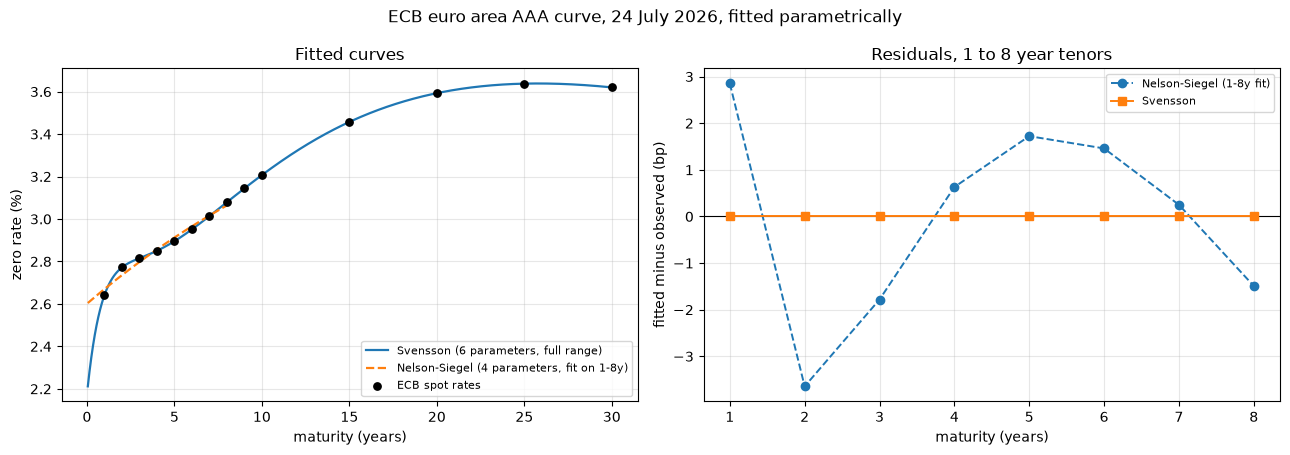

In [8]:
grid = np.linspace(0.05, 30.0, 600)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(
    grid, [100 * sv.zero(t) for t in grid], label="Svensson (6 parameters, full range)", lw=1.6
)
axes[0].plot(
    [t for t in grid if t <= 8],
    [100 * ns.zero(t) for t in grid if t <= 8],
    label="Nelson-Siegel (4 parameters, fit on 1-8y)",
    lw=1.6,
    ls="--",
)
axes[0].scatter(times, 100 * zeros, s=28, zorder=3, color="black", label="ECB spot rates")
axes[0].set_xlabel("maturity (years)")
axes[0].set_ylabel("zero rate (%)")
axes[0].set_title("Fitted curves")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].plot(times[seg], ns_resid_bp, marker="o", lw=1.4, ls="--", label="Nelson-Siegel (1-8y fit)")
axes[1].plot(times[seg], sv_resid_bp, marker="s", lw=1.4, label="Svensson")
axes[1].set_xlabel("maturity (years)")
axes[1].set_ylabel("fitted minus observed (bp)")
axes[1].set_title("Residuals, 1 to 8 year tenors")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.suptitle("ECB euro area AAA curve, 24 July 2026, fitted parametrically")
fig.tight_layout()
plt.show()

## Decomposing the fit into its factors

Both models are linear in the betas, so a fitted curve is the sum of component
curves obtained by keeping one beta and zeroing the rest. Building those
components as `Svensson` objects and adding them back is a check on the claim as
much as an illustration of it.

max |sum of components - fitted curve| = 0.000e+00


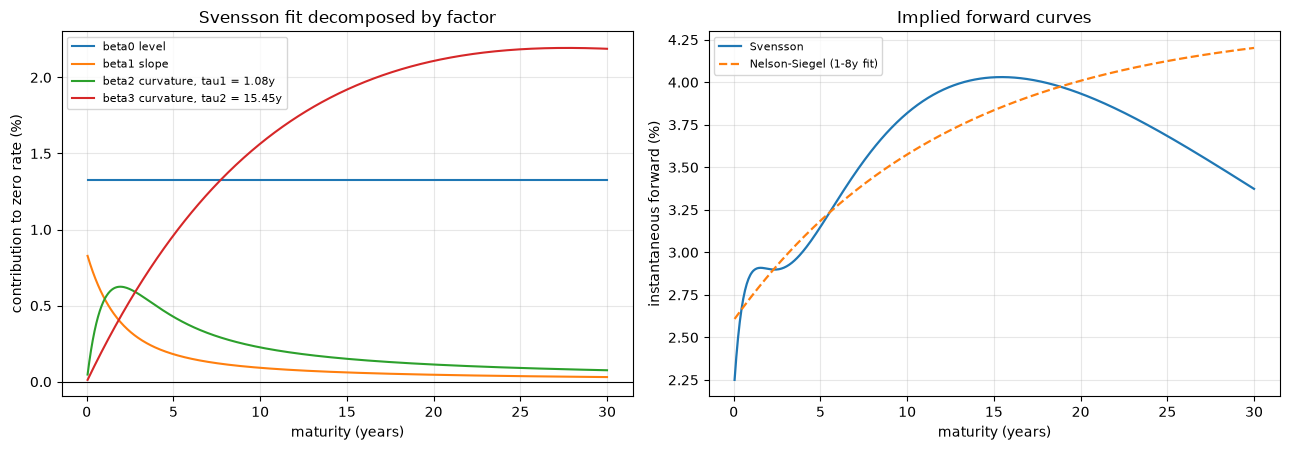

In [9]:
components = {
    f"beta{i}": Svensson(
        beta=tuple(b if j == i else 0.0 for j, b in enumerate(sv.beta)),  # type: ignore[arg-type]
        tau=sv.tau,
        reference_date=ASOF,
    )
    for i in range(4)
}

recombined = np.array([sum(c.zero(t) for c in components.values()) for t in grid])
direct = np.array([sv.zero(t) for t in grid])
print(f"max |sum of components - fitted curve| = {np.abs(recombined - direct).max():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

labels = {
    "beta0": "beta0 level",
    "beta1": "beta1 slope",
    "beta2": "beta2 curvature, tau1 = 1.08y",
    "beta3": "beta3 curvature, tau2 = 15.45y",
}
for name, curve in components.items():
    axes[0].plot(grid, [100 * curve.zero(t) for t in grid], lw=1.5, label=labels[name])
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_xlabel("maturity (years)")
axes[0].set_ylabel("contribution to zero rate (%)")
axes[0].set_title("Svensson fit decomposed by factor")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(grid, [100 * sv.instantaneous_fwd(t) for t in grid], lw=1.6, label="Svensson")
axes[1].plot(
    grid,
    [100 * ns.fwd(t, t + 0.01) for t in grid],
    lw=1.6,
    ls="--",
    label="Nelson-Siegel (1-8y fit)",
)
axes[1].set_xlabel("maturity (years)")
axes[1].set_ylabel("instantaneous forward (%)")
axes[1].set_title("Implied forward curves")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [10]:
# Diagnostics behind the interpretation below. Every figure quoted in the next
# markdown cell is printed here, so the prose can be checked against output.
fine = np.linspace(0.01, 30.0, 3000)


def _peak(component):
    """Maturity and value at which a Svensson component contributes most."""
    vals = [100 * component.zero(t) for t in fine]
    k = int(np.argmax(np.abs(vals)))
    return fine[k], vals[k]


b2_t, b2_v = _peak(components["beta2"])
b3_t, b3_v = _peak(components["beta3"])
print("Svensson component contributions (percentage points of the zero rate)")
print(
    f"  first curvature  peak {b2_v:6.2f}% at {b2_t:5.2f}y"
    f" | at  5y {100 * components['beta2'].zero(5.0):6.2f}%"
    f" | at 15y {100 * components['beta2'].zero(15.0):6.2f}%"
)
print(
    f"  second curvature peak {b3_v:6.2f}% at {b3_t:5.2f}y"
    f" | at 15y {100 * components['beta3'].zero(15.0):6.2f}%"
)

span = fine[(fine >= times[seg].min()) & (fine <= times[seg].max())]
gaps = [abs(100 * (ns.zero(t) - sv.zero(t))) for t in span]
k_gap = int(np.argmax(gaps))
print("\nNelson-Siegel (1-8y fit) against Svensson")
print(
    f"  widest zero-rate gap over 1-8 years     :"
    f" {100 * gaps[k_gap]:6.2f} bp at {span[k_gap]:5.2f}y"
)
print(
    f"  forward-rate gap at 8 years             :"
    f" {1e4 * (ns.fwd(8.0, 8.01) - sv.instantaneous_fwd(8.0)):7.2f} bp"
)

ns_short, sv_short = 100 * ns.zero(1e-9), 100 * sv.zero(1e-9)
print(
    f"  extrapolated to t -> 0                  :"
    f" NS {ns_short:6.2f}%  SV {sv_short:6.2f}%  gap {100 * (ns_short - sv_short):6.2f} bp"
)

print("\nSvensson extrapolation past the last quote (30 years)")
print(f"{'maturity':>9} {'zero %':>11} {'inst fwd %':>11}")
for t in (20.0, 30.0, 40.0, 50.0):
    print(f"{t:>9.0f} {100 * sv.zero(t):>11.4f} {100 * sv.instantaneous_fwd(t):>11.4f}")
print(f"  asymptotic level b0 = {100 * sv.beta[0]:.4f} %")

Svensson component contributions (percentage points of the zero rate)
  first curvature  peak   0.62% at  1.94y | at  5y   0.43% | at 15y   0.15%
  second curvature peak   2.19% at 27.70y | at 15y   1.92%

Nelson-Siegel (1-8y fit) against Svensson
  widest zero-rate gap over 1-8 years     :   3.65 bp at  2.02y
  forward-rate gap at 8 years             :  -16.60 bp
  extrapolated to t -> 0                  : NS   2.60%  SV   2.17%  gap  42.85 bp

Svensson extrapolation past the last quote (30 years)
 maturity      zero %  inst fwd %
       20      3.5929      3.9337
       30      3.6200      3.3734
       40      3.4794      2.7549
       50      3.2826      2.2609
  asymptotic level b0 = 1.3261 %


## Interpretation of results

**Nelson-Siegel residual structure.** On the 1 to 8 year segment where
Nelson-Siegel identifies, its residuals do not scatter around zero. They
alternate sign in runs: positive at 1 year, negative at 2-3, positive through
4-7, negative at 8. This banded pattern identifies a structural deficiency. The
model cannot express the curve's shape because it has only one curvature term,
allowing the forward curve to turn once. The euro area curve turns twice:
concave in the short end, convex in the middle, concave again at long
maturities. The least-squares fit distributes this failure across the segment,
producing residuals of 2.01 basis points RMSE, with the largest single residual
3.64 basis points at 2 years. The Svensson fit's residuals on the same tenors
are of order $10^{-8}$ basis points.

**Parameter identification at boundaries.** On the full 14-point curve,
Nelson-Siegel does not identify at all: the optimizer presses $\beta_0$ against
its floor ($10^{-6}$) and $\tau$ against its ceiling (30 years), and the fit
contract rejects the boundary fit with `FitError` naming the two saturated
parameters. A boundary solution is not an estimate of the market; it is an
estimate of the constraint. The rejection is the library telling the reader that
the curve does not contain enough information to identify the long-run level of
a single-hump model — with $\tau = 30$, the decay is so slow that convergence
has barely begun at 30 years. Svensson's $\beta_0 = 1.326\%$ sits comfortably
interior to the constraints at $\tau_1 = 1.08$ and $\tau_2 = 15.45$ years,
signalling that all six parameters are economically meaningful.

**Two-tau structure.** Decomposing the Svensson fit into its four components
clarifies why two decay constants are essential. The $\beta_2$ term ($\tau_1 =
1.08$ years) peaks at 0.62% around 1.94 years and decays to 0.43% by five years
and 0.15% by fifteen. The $\beta_3$ term ($\tau_2 = 15.45$ years) is still
climbing at fifteen years (contributing 1.92%), reaching its peak of 2.19% at
27.7 years. The two terms operate in separate regions of the curve, which is the
entire purpose of estimating two decay scales. Nelson-Siegel's single scale cannot
capture this separation.

**Magnification of disagreement in forward rates.** Over the 1 to 8 year span
where both models identify, the widest zero-rate gap is 3.65 basis points (near
2 years), while the forward-rate gap at 8 years is 16.6 basis points — the
derivative amplifies a shape disagreement by roughly a factor of four, the same
mechanism measured in notebook 02. Extrapolated back to $t = 0$, Nelson-Siegel
implies 2.60% against Svensson's 2.17%, a 42.85 basis point gap at a maturity
shorter than any observation either model received.

## Extrapolation, and why supervisors prescribe it

The parametric form is defined for all $t$, so the fitted model will return a
rate at 40 or 50 years without complaint. Neither model has seen any data past
30.

In [11]:
# (The extrapolation table is printed in the diagnostics cell above: Svensson
# zero rates and instantaneous forwards at 20, 30, 40 and 50 years, plus the
# fitted asymptotic level b0.)

The printed table shows the fitted Svensson curve rising to 3.64% at 25 years
and then rolling over: 3.62% at 30, 3.48% at 40 and 3.28% at 50, heading for the
asymptotic level $\beta_0 = 1.33\%$ that the fit recovered. The rollover is the
functional form talking, not a market forecast. The second hump term decays as
$e^{-t/\tau_2}$ with $\tau_2 = 15.4$ years, its loading vanishes at long
maturity, and the curve returns to the fitted level — a level that no quote
constrains, because the longest observed maturity is 30 years. The full-data
Nelson-Siegel rejection above is the same fact seen from the other side: 14
quotes to 30 years cannot identify the long-run level of a parametric curve.

Where the market stops supplying information, the number a model returns is a
stated assumption, and supervisors treat it as one. For **Solvency II**
technical provisions, Article 77a of Directive 2009/138/EC requires the
relevant risk-free term structure to be extrapolated beyond the last liquid
point, and EIOPA publishes the prescribed risk-free curves monthly, built with
the Smith-Wilson technique toward a prescribed Ultimate Forward Rate. Both the
last liquid point and the UFR are set by the regulator rather than fitted, which
removes exactly the discretion this table exposes. This notebook implements none
of that: the extrapolation shown here is an educational illustration of model
sensitivity, and nothing in it is suitable for valuing an insurance liability
book.

## Regulatory and control context

**IFRS 13.** A parametric curve is a valuation technique in the sense of IFRS 13,
and its inputs sit at different levels of the fair value hierarchy depending on
where they came from. The 50 year rate in the table above, produced by
extrapolating the fitted model past its data, depends on unobservable inputs —
the assumed functional form, the asymptotic level $\beta_0$ and the decay
$\tau_2$ — and IFRS 13 defines an unobservable input as a Level 3 input. No
automatic classification of any measurement follows from that: the hierarchy
level of a fair-value measurement depends on the significance of the
lowest-level significant input (IFRS 13.72-74), and this notebook performs no
entity-level fair-value measurement. Where the curve stops being observable is
therefore an accounting question for the entity using the curve, not a property
this notebook can assert.

**CRR Article 105 and the EBA prudent valuation RTS.** Prudent valuation
requires institutions to hold additional valuation adjustments — capital —
against the range of plausible values of the positions they hold. That is an
institution-level obligation on positions an institution actually holds. The
model dispersion measured in this notebook is an educational illustration of
model risk; it is not an AVA calculation, and no capital treatment is implied
by anything in this repository.

**Model risk.** The full-data Nelson-Siegel rejection is the sort of finding a
model validation function exists to catch: a plausible-looking fit that quietly
presses two parameters against their bounds would pass a review that inspected
only residuals. The library's fit contract now makes that failure loud —
`FitError` naming the saturated parameters — which is exactly the behaviour a
validation review wants from a fitter.

## Limitations of this implementation

Two are worth recording rather than leaving for a reader to discover.

**The positive short rate constraint.** Both fitters reject any candidate with
$\beta_0 + \beta_1 \le 10^{-6}$, so neither can represent a negative instantaneous
short rate. For euro area data between 2015 and 2022 that is not a safeguard, it
is a specification error: the short end of the euro curve was genuinely negative
for most of that period, and this fitter could not have described it. The
constraint is defensible for the July 2026 curve fitted here, where the one year
rate is 2.64%, and it is not defensible in general. Notebook 02 made the opposite
choice in the interpolation layer, deliberately omitting the Hagan-West positivity
amendment for precisely this reason. The inconsistency between the two modules is
real and this notebook is the right place to say so.

**The bounds are not neutral, and the fitter now says so.** The full-data
Nelson-Siegel fit pressed $\beta_0$ against its floor and $\tau$ against its
ceiling and was rejected with `FitError` rather than silently returned; the 1 to
8 year fit that identifies does so only after the user chooses a sub-range. The
rejection is deliberate (the fit contract of `yieldcurve.curves.parametric`),
but the cost is real: the user must either restrict the data or change the
model, and the segment choice is a modelling decision the notebook states
openly rather than hiding.

## Summary

Two parametric models were fitted to the 14 point ECB euro area AAA spot curve
for 24 July 2026.

The Svensson fit recovered the ECB's six published parameters to about eight
significant figures, from the spot rates alone, and reported full-rank
identification diagnostics. Because the ECB generates those spot rates from its
own Svensson estimation, that agreement is a planted-data verification of this
implementation's functional form and optimiser, not evidence about how well
Svensson prices bonds. The independent check is the ECB Svensson reconstruction
named in the validation section: the published parameters rebuild the published
spot curve (max error printed above), and a hand-written closed-form evaluation
reproduces both the fitted curve and the observed rates at 5, 10 and 30 years to
machine precision.

Nelson-Siegel, the same model without the second curvature term, cannot be
fitted to the full 14-point curve at all: its optimum presses $\beta_0$ and
$\tau$ against their bounds, and the fit contract rejects the boundary fit with
`FitError`. On the 1 to 8 year segment, where its parameters identify, it fits
with a 2.01 basis point RMSE and a largest single residual of 3.64 basis points
at 2 years, and its residuals alternate sign in runs that identify the problem
as missing shape rather than imprecision: one curvature term cannot turn the
forward curve twice, and this curve turns twice.

Extrapolated past the data, the fitted Svensson curve rolls over after 25 years
toward its fitted asymptotic level of 1.33%, a value no quote constrains; at 50
years it reports 3.28%. Extrapolated values are unobservable inputs — a stated
modelling choice — and the notebook makes no claim that they are fit to
anything.

Notebook 04 leaves single-currency curve shape behind and takes up the
post-2008 multi-curve framework, where discounting and forecasting are done off
separate curves.